# Normalized fuel-consumption speed versus stretch

This notebook computes the normalized fuel-consumption-speed curve,

$$
\frac{s_{c,\dot{\omega}}}{s_L},
$$

for two chemical mechanisms:

| Case | Mechanism | Purpose |
|---:|---|---|
| 1 | GRI-Mech 3.0 | Detailed chemistry comparison case |
| 2 | Detomaso two-step propane mechanism | Direct comparison against Detomaso et al. |

The computed curves are compared against the corresponding digitized data from Detomaso et al.

The fuel-consumption speed is evaluated from the integrated fuel consumption rate:

$$
s_{c,\dot{\omega}}
=
-\frac{1}{\rho_u \left( Y_{F,u} - Y_{F,b} \right)}
\int \dot{\omega}_F \, dx .
$$

The plotted value is then normalized by the freely propagating laminar flame speed for the same mechanism:

$$
\frac{s_{c,\dot{\omega}}}{s_L}.
$$

Cantera returns species production rates in kmol/m$^3$/s. Therefore, the script multiplies the fuel production rate by the fuel molecular weight before integrating the fuel source term.

## Comparison with Detomaso et al.

The present implementation gives a 1–5% mismatch in $s_{c,\dot{\omega}}/s_L$ compared with the digitized Detomaso data. This difference is relatively consistent across stretch levels. Therefore, the derived thickening-factor relationships $F_{\mathrm{th}}$, $F_{\mathrm{sp}}$, and $F_r$ are expected to remain close to the values reported by Detomaso et al.

The agreement is considered sufficient for validating the implementation workflow used here, particularly the calculation of the correction factors $F_{\mathrm{sp}}$, $F_r$, and $\hat{Le}$. The larger percentage differences in $X_0$ should be interpreted carefully because $X_0$ crosses zero; in that case, the absolute difference is often more meaningful than the percentage difference.

| $F$ | $X_0$ present | $X_0$ Detomaso | $\Delta X_0$ | $X_0$ diff [%] | $F_{\mathrm{sp}}$ present | $F_{\mathrm{sp}}$ Detomaso | $F_{\mathrm{sp}}$ diff [%] | $F_r$ present | $F_r$ Detomaso | $F_r$ diff [%] | $\hat{Le}$ present | $\hat{Le}$ Detomaso | $\hat{Le}$ diff [%] |
|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|---:|
| 1.00 | 1.00000 | 1.00000 | 0.00000 | 0.0000 | 1.00000 | 1.00000 | 0.0000 | 1.000000 | 1.000000 | 0.0000 | 1.40000 | 1.40000 | 0.0000 |
| 2.00 | 1.10000 | 0.95000 | 0.15000 | 15.7895 | 2.29508 | 2.35300 | -2.4615 | 1.802375 | 1.769912 | 1.8342 | 1.22000 | 1.19000 | 2.5210 |
| 5.00 | 0.79475 | 0.62000 | 0.17475 | 28.1847 | 6.58155 | 6.66900 | -1.3113 | 4.061957 | 4.016064 | 1.1427 | 1.06358 | 1.05000 | 1.2933 |
| 7.00 | 0.17344 | -0.20000 | 0.37344 | -186.7208 | 9.70383 | 9.91300 | -2.1101 | 5.468438 | 5.376344 | 1.7129 | 1.00991 | 0.98900 | 2.1144 |
| 10.00 | -1.17996 | -1.20000 | 0.02004 | -1.6701 | 14.69351 | 14.70600 | -0.0849 | 7.475721 | 7.462687 | 0.1747 | 0.95280 | 0.95200 | 0.0842 |

## Mean absolute percentage differences

| Quantity | Mean absolute percentage difference |
|---|---:|
| $F_{\mathrm{sp}}$ | 1.19356% |
| $F_r$ | 0.97291% |
| $\hat{Le}$ | 1.20257% |

Overall, the present results reproduce the Detomaso-derived correction factors to approximately 1–2% mean absolute percentage difference. This provides a useful validation check for the implementation of the stretched-thickened flame correction-factor workflow.

In [3]:
import csv
import os
import time
from pathlib import Path

import cantera as ct
import matplotlib.pyplot as plt
import numpy as np


In [4]:

# =============================================================================
# USER SETTINGS
# =============================================================================

Tu = 300.0
pressure = 1e5
phi = 0.9

fuel = "C3H8:1"
fuel_species = "C3H8"
oxidizer = "O2:0.21, N2:0.79"

# The paper says L is close to 100 delta_L0.
domain_length_multiplier = 100.0

free_flame_width = 0.04

loglevel = 0

refine_criteria = {
    "ratio": 2.0,
    "slope": 0.02,
    "curve": 0.02,
    "prune": 0
}

results_csv_filename = "sc_omega_v_kappa_results.csv"
gri_figure_filename = "gri_sc_omega_over_sL_vs_detomaso_paper.png"
two_step_figure_filename = "2s_sc_omega_over_sL_vs_detomaso_paper.png"

# Digitized Detomaso-paper data files.
# GRI data is embedded below as a fallback because it was supplied in the prompt.
# The CSV y-column is assumed to be the dimensional paper speed in mm/s.
gri_paper_csv_filename = "gri_scq_v_kappa.csv"
two_step_paper_csv_filename = "2s_scq_v_kappa.csv"


In [5]:

# =============================================================================
# DIGITIZED PAPER DATA
# =============================================================================

# Columns are:
#   x = kappa or global strain rate [1/s]
#   y = digitized paper speed [mm/s]
# The plotting block normalizes y by sL before plotting.


def load_two_column_curve(filename, fallback_data=None):
    """
    Load a two-column digitized curve from a CSV file.

    Expected columns are x,y, but spaces in the header are tolerated.
    If the file is missing and fallback_data is supplied, the fallback is used.
    """

    path = Path(filename)

    if not path.exists():
        if fallback_data is None:
            raise FileNotFoundError(
                f"Could not find '{filename}'. Put this CSV file in the "
                f"same directory as the notebook before running."
            )

        return np.asarray(
            fallback_data,
            dtype=float,
        )

    rows = []

    with open(
        path,
        "r",
        newline="",
        encoding="utf-8",
    ) as csv_file:
        reader = csv.DictReader(
            csv_file
        )

        fieldnames = [
            name.strip()
            for name in reader.fieldnames
        ]

        for raw_row in reader:
            row = {
                key.strip(): value
                for key, value in raw_row.items()
            }

            rows.append(
                [
                    float(row[fieldnames[0]]),
                    float(row[fieldnames[1]]),
                ]
            )

    curve = np.asarray(
        rows,
        dtype=float,
    )

    curve = curve[
        np.argsort(
            curve[:, 0]
        )
    ]

    return curve


def unique_positive_kappa_values(curve):
    """Return sorted positive kappa values from a paper curve."""

    return np.unique(
        curve[:, 0][curve[:, 0] > 0.0]
    )


gri_paper_curve = load_two_column_curve(
    gri_paper_csv_filename
)

two_step_paper_curve = load_two_column_curve(
    two_step_paper_csv_filename,
)

print(f"Loaded {len(gri_paper_curve)} GRI paper points.")
print(f"Loaded {len(two_step_paper_curve)} two-step paper points.")


Loaded 11 GRI paper points.
Loaded 10 two-step paper points.


In [6]:

# =============================================================================
# MECHANISM CASES
# =============================================================================

mechanism_cases = [
    {
        "key": "gri30",
        "label": "GRI-Mech 3.0",
        "mechanism_file": "gri30.yaml",
        "transport_model": "mixture-averaged",
        "use_constant_transport_numbers": False,
        "lewis_number": np.nan,
        "prandtl_number": np.nan,
        "paper_curve": gri_paper_curve,
        # Set this to the paper's reported sL0 in mm/s if you want to
        # normalize the digitized paper data by the paper value instead of
        # this script's computed free-flame speed.
        "paper_sL0_mm_s": None,
        "figure_filename": gri_figure_filename,
        "plot_title": r"GRI-Mech 3.0: $s_{c,\omega}/s_L$ versus Detomaso paper",
        "computed_label": r"This script: GRI $s_{c,\omega}/s_L$",
        "paper_label": r"Detomaso paper: GRI digitized curve / $s_L$",
        "plot_style": {
            "linestyle": "-",
            "marker": "o",
            "linewidth": 2.0,
            "markersize": 5.0,
        },
        "paper_style": {
            "linestyle": "None",
            "marker": "s",
            "markersize": 5.0,
        },
    },
    {
        "key": "detomaso_2s",
        "label": "Detomaso 2S $F=1$",
        "mechanism_file": "detomaso_propane_2step_nopea.yaml",
        "transport_model": "simplified",
        "use_constant_transport_numbers": True,
        "lewis_number": 1.4,
        "prandtl_number": 0.7,
        "paper_curve": two_step_paper_curve,
        # Set this to the paper's reported sL0 in mm/s if available.
        "paper_sL0_mm_s": None,
        "figure_filename": two_step_figure_filename,
        "plot_title": r"Detomaso two-step: $s_{c,\omega}/s_L$ versus Detomaso paper",
        "computed_label": r"This script: 2S $s_{c,\omega}/s_L$",
        "paper_label": r"Detomaso paper: 2S digitized curve / $s_L$",
        "plot_style": {
            "linestyle": "-",
            "marker": "o",
            "linewidth": 2.0,
            "markersize": 5.0,
        },
        "paper_style": {
            "linestyle": "None",
            "marker": "s",
            "markersize": 5.0,
        },
    },
]


In [7]:

# =============================================================================
# BASIC HELPERS
# =============================================================================

def set_unburned_state(gas):
    """Set the fresh propane-air mixture state."""

    gas.TP = Tu, pressure

    gas.set_equivalence_ratio(
        phi,
        fuel=fuel,
        oxidizer=oxidizer,
        basis="mole",
    )


def apply_transport_model(obj, transport_model):
    """Apply the requested Cantera transport model."""

    if transport_model is None:
        return

    try:
        obj.transport_model = transport_model

    except Exception as error:
        raise RuntimeError(
            f"Could not set transport model '{transport_model}'."
        ) from error


def apply_constant_transport_numbers(gas, case):
    """
    Apply constant Lewis and Prandtl numbers for your custom simplified
    transport model.
    """

    if not case["use_constant_transport_numbers"]:
        return

    gas.set_lewis_number(
        case["lewis_number"]
    )

    gas.set_prandtl_number(
        case["prandtl_number"]
    )


def make_gas(case):
    """
    Create a Cantera gas object with mixture state, transport model,
    and optional constant Le/Pr settings.
    """

    gas = ct.Solution(
        case["mechanism_file"]
    )

    set_unburned_state(
        gas
    )

    apply_transport_model(
        gas,
        case["transport_model"],
    )

    apply_constant_transport_numbers(
        gas,
        case,
    )

    return gas


def integrate_profile(values, grid):
    """Integrate a profile while supporting different NumPy versions."""

    if hasattr(np, "trapezoid"):
        return np.trapezoid(
            values,
            grid,
        )

    return np.trapz(
        values,
        grid,
    )


In [8]:

# =============================================================================
# BOUNDARY AND FLAME-SCALE FUNCTIONS
# =============================================================================

def build_boundary_state(case):
    """Calculate unburned and equilibrium-burned inlet states for one mechanism."""

    gas_u = make_gas(
        case
    )

    fuel_index = gas_u.species_index(
        fuel_species
    )

    molecular_weight_fuel = float(
        gas_u.molecular_weights[fuel_index]
    )

    rho_u = float(
        gas_u.density
    )

    Y_u = gas_u.Y.copy()

    gas_b = make_gas(
        case
    )

    gas_b.equilibrate(
        "HP"
    )

    rho_b = float(
        gas_b.density
    )

    T_b = float(
        gas_b.T
    )

    Y_b = gas_b.Y.copy()

    return {
        "rho_u": rho_u,
        "Y_u": Y_u,
        "rho_b": rho_b,
        "T_b": T_b,
        "Y_b": Y_b,
        "fuel_index": fuel_index,
        "molecular_weight_fuel": molecular_weight_fuel,
    }


def calculate_thermal_flame_thickness(
    flame,
    boundary,
):
    """
    Thermal flame thickness:

        delta_L0 = (T_b - T_u) / max |dT/dx|
    """

    grid = np.asarray(
        flame.grid,
        dtype=float,
    )

    temperature = np.asarray(
        flame.T,
        dtype=float,
    )

    dT_dx = np.gradient(
        temperature,
        grid,
        edge_order=2,
    )

    delta_L0 = (
        boundary["T_b"]
        - Tu
    ) / np.max(
        np.abs(dT_dx)
    )

    return float(delta_L0)


In [9]:

# =============================================================================
# s_c,omega FUNCTION
# =============================================================================

def calculate_sc_omega(
    flame,
    boundary,
):
    """
    Calculate fuel-consumption speed from integrated fuel consumption:

        sc_omega = - integral(omega_F dx)
                   / [rho_u (Y_F,u - Y_F,b)]

    Cantera net_production_rates are kmol/m3/s.
    Multiplication by the fuel molecular weight gives kg/m3/s.
    """

    grid = np.asarray(
        flame.grid,
        dtype=float,
    )

    net_production_rates = np.asarray(
        flame.net_production_rates,
        dtype=float,
    )

    fuel_index = boundary["fuel_index"]

    omega_fuel_mass = (
        net_production_rates[fuel_index, :]
        * boundary["molecular_weight_fuel"]
    )

    integrated_fuel_rate = float(
        integrate_profile(
            omega_fuel_mass,
            grid,
        )
    )

    delta_Y_fuel = float(
        boundary["Y_u"][fuel_index]
        - boundary["Y_b"][fuel_index]
    )

    denominator = (
        boundary["rho_u"]
        * delta_Y_fuel
    )

    if denominator <= 0.0:
        raise RuntimeError(
            "The fresh-to-burned fuel mass-fraction difference is not positive."
        )

    sc_omega = float(
        -integrated_fuel_rate
        / denominator
    )

    return sc_omega, integrated_fuel_rate


In [10]:

# =============================================================================
# SOLVER FUNCTIONS
# =============================================================================

def solve_unstretched_flame(case):
    """Solve the freely propagating reference flame for one mechanism."""

    gas = make_gas(
        case
    )

    flame = ct.FreeFlame(
        gas,
        width=free_flame_width,
    )

    apply_transport_model(
        flame,
        case["transport_model"],
    )

    flame.set_refine_criteria(
        **refine_criteria
    )

    # Critical for your cantera-tcd simplified transport model.
    apply_constant_transport_numbers(
        gas,
        case,
    )

    flame.solve(
        loglevel=loglevel,
        auto=True,
    )

    sL0 = float(
        flame.velocity[0]
    )

    if (
        not np.isfinite(sL0)
        or sL0 <= 0.0
    ):
        raise RuntimeError(
            f"Invalid freely propagating flame speed: {sL0}"
        )

    return {
        "sL0": sL0,
        "Tmax": float(
            np.max(flame.T)
        ),
        "n_points": int(
            flame.grid.size
        ),
        "flame": flame,
    }


def inlet_velocities_for_target_kappa(
    kappa_target,
    rho_u,
    rho_b,
    domain_length,
):
    """
    Select inlet velocities satisfying:

        kappa_global = (|Uu| + |Ub|) / L

    while retaining the equal-dynamic-pressure relationship:

        rho_u * Uu^2 = rho_b * Ub^2
    """

    if kappa_target < 0.0:
        raise ValueError(
            "kappa_target must be non-negative."
        )

    if kappa_target == 0.0:
        return 0.0, 0.0

    velocity_ratio = np.sqrt(
        rho_u
        / rho_b
    )

    Uu = (
        kappa_target
        * domain_length
        / (
            1.0
            + velocity_ratio
        )
    )

    Ub = velocity_ratio * Uu

    return float(Uu), float(Ub)


def solve_counterflow_case(
    case,
    boundary,
    kappa_target,
    domain_length,
):
    """Solve one counterflow premixed flame case."""

    Uu, Ub = inlet_velocities_for_target_kappa(
        kappa_target,
        boundary["rho_u"],
        boundary["rho_b"],
        domain_length,
    )

    gas = make_gas(
        case
    )

    flame = ct.CounterflowPremixedFlame(
        gas,
        width=domain_length,
    )

    apply_transport_model(
        flame,
        case["transport_model"],
    )

    flame.reactants.T = Tu
    flame.reactants.Y = boundary["Y_u"]
    flame.reactants.mdot = (
        boundary["rho_u"]
        * Uu
    )

    flame.products.T = boundary["T_b"]
    flame.products.Y = boundary["Y_b"]
    flame.products.mdot = (
        boundary["rho_b"]
        * Ub
    )

    flame.set_initial_guess(
        equilibrate=False,
    )

    flame.set_refine_criteria(
        **refine_criteria
    )

    # Critical for the Detomaso two-step simplified-transport case.
    apply_constant_transport_numbers(
        gas,
        case,
    )

    flame.solve(
        loglevel=loglevel,
        refine_grid=True,
        auto=True,
    )

    temperature = np.asarray(
        flame.T,
        dtype=float,
    )

    Tmax = float(
        np.max(temperature)
    )

    if Tmax < Tu + 500.0:
        raise RuntimeError(
            f"Cold or extinguished solution detected at "
            f"kappa_target={kappa_target:g} 1/s for {case['label']}."
        )

    sc_omega, integrated_fuel_rate = calculate_sc_omega(
        flame,
        boundary,
    )

    if (
        not np.isfinite(sc_omega)
        or sc_omega <= 0.0
    ):
        raise RuntimeError(
            f"Invalid sc_omega at "
            f"kappa_target={kappa_target:g} 1/s for {case['label']}: {sc_omega}"
        )

    kappa_global = float(
        (
            abs(Uu)
            + abs(Ub)
        )
        / domain_length
    )

    return {
        "kappa_target": float(
            kappa_target
        ),
        "kappa_global": kappa_global,
        "domain_length": float(
            domain_length
        ),
        "Uu": float(Uu),
        "Ub": float(Ub),
        "sc_omega": sc_omega,
        "sc_omega_mm_s": sc_omega * 1000.0,
        "Tmax": Tmax,
        "n_points": int(
            flame.grid.size
        ),
        "integrated_fuel_rate": integrated_fuel_rate,
    }


In [11]:

# =============================================================================
# CHECK BLOCK
# =============================================================================

def check_unstretched_flame_scales(
    case,
    reference,
    boundary,
):
    """Print free-flame scale checks for one mechanism."""

    flame = reference["flame"]

    sL0_inlet = reference["sL0"]

    sL0_integral, integrated_fuel_rate = calculate_sc_omega(
        flame,
        boundary,
    )

    delta_L0 = calculate_thermal_flame_thickness(
        flame,
        boundary,
    )

    grid = np.asarray(
        flame.grid,
        dtype=float,
    )

    T = np.asarray(
        flame.T,
        dtype=float,
    )

    dT_dx = np.gradient(
        T,
        grid,
        edge_order=2,
    )

    flame_index = int(
        np.argmax(
            np.abs(dT_dx)
        )
    )

    print(f"\nUnstretched flame scale check: {case['label']}")
    print("=" * 78)
    print(f"mechanism file                  = {case['mechanism_file']}")
    print(f"transport model                 = {case['transport_model']}")
    print(f"sL0 from inlet velocity         = {sL0_inlet:.8f} m/s")
    print(f"sL0 from omega integral         = {sL0_integral:.8f} m/s")
    print(f"omega integral / inlet ratio    = {sL0_integral / sL0_inlet:.8f}")
    print("-" * 78)
    print(f"T_u                             = {Tu:.3f} K")
    print(f"T_b used for delta_L0           = {boundary['T_b']:.3f} K")
    print(f"T_max in free flame             = {np.max(T):.3f} K")
    print(f"max |dT/dx|                     = {np.max(np.abs(dT_dx)):.6e} K/m")
    print("-" * 78)
    print(f"delta_L0                        = {delta_L0:.8e} m")
    print(f"delta_L0                        = {delta_L0 * 1000.0:.6f} mm")
    print(f"sL0 / delta_L0                  = {sL0_inlet / delta_L0:.2f} 1/s")
    print(f"delta_L0 / sL0                  = {delta_L0 / sL0_inlet * 1000.0:.6f} ms")
    print("-" * 78)
    print(f"x at max |dT/dx|                = {grid[flame_index] * 1000.0:.6f} mm")
    print(f"T at max |dT/dx|                = {T[flame_index]:.3f} K")
    print(f"free-flame grid points          = {grid.size}")
    print("=" * 78)

    return {
        "sL0_omega_integral": sL0_integral,
        "sL0_omega_integral_over_inlet": sL0_integral / sL0_inlet,
        "integrated_fuel_rate": integrated_fuel_rate,
        "delta_L0": delta_L0,
        "delta_L0_mm": delta_L0 * 1000.0,
        "sL0_over_delta_L0": sL0_inlet / delta_L0,
    }


In [12]:

# =============================================================================
# MAIN RUN
# =============================================================================

print(f"Cantera version: {ct.__version__}")
print(f"phi = {phi}")
print(f"Tu = {Tu} K")
print(f"pressure = {pressure} Pa")

all_results = []

overall_start = time.perf_counter()

for case in mechanism_cases:
    print("\n" + "#" * 90)
    print(f"Running case: {case['label']}")
    print("#" * 90)

    print(f"Mechanism:       {case['mechanism_file']}")
    print(f"Transport model: {case['transport_model']}")

    if case["use_constant_transport_numbers"]:
        print(f"Target Lewis number:   {case['lewis_number']}")
        print(f"Target Prandtl number: {case['prandtl_number']}")

    boundary = build_boundary_state(
        case
    )

    print("\nBoundary properties")
    print("-" * 60)
    print(f"Unburned density:    {boundary['rho_u']:.6f} kg/m3")
    print(f"Burned density:      {boundary['rho_b']:.6f} kg/m3")
    print(f"Burned temperature:  {boundary['T_b']:.3f} K")

    print("\nSolving freely propagating reference flame...")

    reference = solve_unstretched_flame(
        case
    )

    sL0 = reference["sL0"]

    print(f"sL0 = {sL0:.8f} m/s")
    print(f"sL0 = {sL0 * 1000.0:.4f} mm/s")
    print(f"Tmax = {reference['Tmax']:.3f} K")
    print(f"Grid points = {reference['n_points']}")

    scale_check = check_unstretched_flame_scales(
        case,
        reference,
        boundary,
    )

    delta_L0 = scale_check["delta_L0"]

    domain_length = (
        domain_length_multiplier
        * delta_L0
    )

    print("\nCounterflow domain")
    print("-" * 60)
    print(f"delta_L0                 = {delta_L0 * 1000.0:.6f} mm")
    print(f"L = {domain_length_multiplier:.1f} delta_L0 = {domain_length:.8e} m")
    print(f"L                        = {domain_length * 1000.0:.6f} mm")

    all_results.append(
        {
            "case_key": case["key"],
            "label": case["label"],
            "mechanism": case["mechanism_file"],
            "transport_model": case["transport_model"],
            "Le": case["lewis_number"],
            "Pr": case["prandtl_number"],
            "domain_length": domain_length,
            "delta_L0": delta_L0,
            "sL0_over_delta_L0": sL0 / delta_L0,
            "kappa_target": 0.0,
            "kappa_global": 0.0,
            "Uu": 0.0,
            "Ub": 0.0,
            "sL0": sL0,
            "sL0_mm_s": sL0 * 1000.0,
            "sc_omega": sL0,
            "sc_omega_mm_s": sL0 * 1000.0,
            "sc_omega_over_sL0": 1.0,
            "Tmax": reference["Tmax"],
            "n_points": reference["n_points"],
            "integrated_fuel_rate": np.nan,
            "status": "free-flame reference",
        }
    )

    kappa_targets = unique_positive_kappa_values(
        case["paper_curve"]
    )

    print(f"\nRequested kappa values from paper curve: {kappa_targets}")

    print(
        "\n"
        "case | target kappa | global kappa | "
        "Uu [m/s] | Ub [m/s] | sc_omega [mm/s] | sc_omega/sL0"
    )

    print("-" * 112)

    for case_number, kappa_target in enumerate(
        kappa_targets,
        start=1,
    ):
        try:
            result = solve_counterflow_case(
                case,
                boundary,
                kappa_target,
                domain_length,
            )

            normalized_speed = float(
                result["sc_omega"]
                / sL0
            )

            row = {
                "case_key": case["key"],
                "label": case["label"],
                "mechanism": case["mechanism_file"],
                "transport_model": case["transport_model"],
                "Le": case["lewis_number"],
                "Pr": case["prandtl_number"],
                "delta_L0": delta_L0,
                "sL0_over_delta_L0": sL0 / delta_L0,
                "sL0": sL0,
                "sL0_mm_s": sL0 * 1000.0,
                "sc_omega_over_sL0": normalized_speed,
                "status": "converged",
                **result,
            }

            all_results.append(
                row
            )

            print(
                f"{case_number:4d} | "
                f"{result['kappa_target']:12.3f} | "
                f"{result['kappa_global']:12.3f} | "
                f"{result['Uu']:8.4f} | "
                f"{result['Ub']:8.4f} | "
                f"{result['sc_omega_mm_s']:15.4f} | "
                f"{normalized_speed:13.5f}"
            )

        except Exception as error:
            print(
                f"{case_number:4d} | "
                f"{kappa_target:12.3f} | FAILED: "
                f"{type(error).__name__}: {error}",
                flush=True,
            )

elapsed = time.perf_counter() - overall_start

print(
    f"\nStored {len(all_results)} points "
    f"in {elapsed:.1f} seconds."
)


Cantera version: 4.0.0a1
phi = 0.9
Tu = 300.0 K
pressure = 100000.0 Pa

##########################################################################################
Running case: GRI-Mech 3.0
##########################################################################################
Mechanism:       gri30.yaml
Transport model: mixture-averaged

Boundary properties
------------------------------------------------------------
Unburned density:    1.178908 kg/m3
Burned density:      0.156081 kg/m3
Burned temperature:  2178.832 K

Solving freely propagating reference flame...
sL0 = 0.44120682 m/s
sL0 = 441.2068 mm/s
Tmax = 2188.639 K
Grid points = 617

Unstretched flame scale check: GRI-Mech 3.0
mechanism file                  = gri30.yaml
transport model                 = mixture-averaged
sL0 from inlet velocity         = 0.44120682 m/s
sL0 from omega integral         = 0.44060354 m/s
omega integral / inlet ratio    = 0.99863267
---------------------------------------------------------------

In [13]:

# =============================================================================
# EXPORT CSV
# =============================================================================

result_rows = sorted(
    all_results,
    key=lambda row: (
        row["case_key"],
        row["kappa_global"],
    ),
)

fieldnames = [
    "case_key",
    "label",
    "mechanism",
    "transport_model",
    "Le",
    "Pr",
    "domain_length",
    "delta_L0",
    "sL0_over_delta_L0",
    "kappa_target",
    "kappa_global",
    "Uu",
    "Ub",
    "sL0",
    "sL0_mm_s",
    "sc_omega",
    "sc_omega_mm_s",
    "sc_omega_over_sL0",
    "Tmax",
    "n_points",
    "integrated_fuel_rate",
    "status",
]

with open(
    results_csv_filename,
    "w",
    newline="",
    encoding="utf-8",
) as csv_file:
    writer = csv.DictWriter(
        csv_file,
        fieldnames=fieldnames,
    )

    writer.writeheader()
    writer.writerows(
        result_rows
    )

print(
    f"\nSaved numerical results to:\n"
    f"{os.path.abspath(results_csv_filename)}"
)



Saved numerical results to:
/home/cilo479/Documents/cantera-tcd/samples/python/stretchedTF/sc_omega_v_kappa_results.csv


Using existing all_results from memory. No simulations rerun.


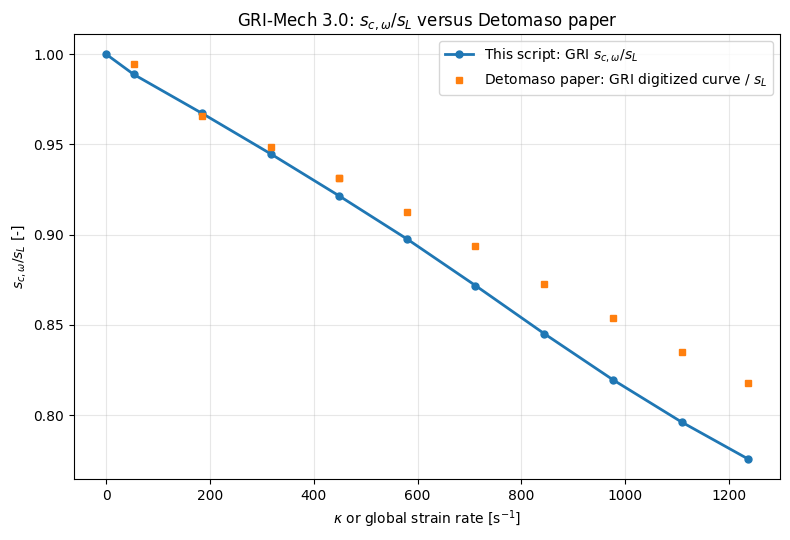

Computed sL0 used for this script: 441.2068 mm/s
sL0 used to normalize paper data: 441.2068 mm/s
Saved figure to:
/home/cilo479/Documents/cantera-tcd/samples/python/stretchedTF/gri_sc_omega_over_sL_vs_detomaso_paper.png


In [14]:
# =============================================================================
# PLOT BLOCK 1: GRI s_c,omega/sL VERSUS DETOMASO-PAPER GRI DATA
# =============================================================================
# This block does NOT need to rerun the Cantera simulations.
# It uses all_results if it already exists in memory. If not, it reloads the
# previously exported results CSV and normalizes the stored sc_omega values by sL0.

RESULTS_CSV_CANDIDATES = [
    results_csv_filename,
    "sc_omega_v_kappa_results.csv",
    "sc_omega_over_sL_v_kappa_results.csv",
]


def convert_csv_value(value):
    """Convert CSV strings to float where possible."""

    if value is None:
        return value

    text = str(value).strip()

    if text == "":
        return np.nan

    try:
        return float(text)
    except ValueError:
        return text


def load_results_rows_from_csv(filename):
    """Load previously exported simulation results from CSV."""

    path = Path(filename)

    if not path.exists():
        raise FileNotFoundError(
            f"Could not find results CSV: {filename}"
        )

    rows = []

    with open(
        path,
        "r",
        newline="",
        encoding="utf-8",
    ) as csv_file:
        reader = csv.DictReader(
            csv_file
        )

        for raw_row in reader:
            row = {
                key: convert_csv_value(value)
                for key, value in raw_row.items()
            }

            # Older files may not have the normalized column. Recompute it
            # from the dimensional sc_omega and the stored free-flame speed.
            if (
                "sc_omega_over_sL0" not in row
                or not np.isfinite(float(row["sc_omega_over_sL0"]))
            ):
                row["sc_omega_over_sL0"] = (
                    float(row["sc_omega_mm_s"])
                    / float(row["sL0_mm_s"])
                )

            rows.append(
                row
            )

    print(
        f"Loaded existing simulation results from:\n{path.resolve()}"
    )

    return rows


def get_results_rows_for_plotting():
    """Use in-memory results if available; otherwise reload the exported CSV."""

    if (
        "all_results" in globals()
        and isinstance(all_results, list)
        and len(all_results) > 0
    ):
        print(
            "Using existing all_results from memory. No simulations rerun."
        )
        return all_results

    checked_paths = []

    for filename in RESULTS_CSV_CANDIDATES:
        path = Path(filename)
        checked_paths.append(
            str(path.resolve())
        )

        if path.exists():
            return load_results_rows_from_csv(
                filename
            )

    raise FileNotFoundError(
        "No in-memory all_results were found and no exported results CSV was found.\n"
        "Checked:\n"
        + "\n".join(checked_paths)
        + "\n\nRun the MAIN RUN block once, or put the previous results CSV in this folder."
    )


plot_results = get_results_rows_for_plotting()


def get_case_rows(case_key):
    """Return sorted rows for one mechanism case."""

    rows = [
        row
        for row in plot_results
        if row["case_key"] == case_key
    ]

    rows = [
        row
        for row in rows
        if np.isfinite(float(row["kappa_global"]))
        and np.isfinite(float(row["sc_omega_over_sL0"]))
    ]

    return sorted(
        rows,
        key=lambda row: float(row["kappa_global"]),
    )


def get_case_sL0_mm_s(rows):
    """Return the computed free-flame speed in mm/s for one mechanism case."""

    if not rows:
        raise RuntimeError(
            "No computed rows found for this mechanism case."
        )

    sL0_values = np.array(
        [
            float(row["sL0_mm_s"])
            for row in rows
        ],
        dtype=float,
    )

    return float(
        np.nanmean(
            sL0_values
        )
    )


def get_paper_sL0_mm_s(case, computed_sL0_mm_s):
    """
    Return the speed used to normalize the digitized paper curve.

    By default, the paper y-data are divided by this script's computed sL0
    for that mechanism. If the paper's reported sL0 is known, set
    case["paper_sL0_mm_s"] to that value in the mechanism_cases block.
    """

    paper_sL0_mm_s = case.get(
        "paper_sL0_mm_s",
        None,
    )

    if paper_sL0_mm_s is None:
        return computed_sL0_mm_s

    return float(
        paper_sL0_mm_s
    )


def plot_case_against_paper(case):
    """Plot computed sc_omega/sL against the normalized paper curve."""

    rows = get_case_rows(
        case["key"]
    )

    if not rows:
        raise RuntimeError(
            f"No result rows found for case_key='{case['key']}'."
        )

    kappa_values = np.array(
        [
            float(row["kappa_global"])
            for row in rows
        ],
        dtype=float,
    )

    sc_omega_over_sL_values = np.array(
        [
            float(row["sc_omega_over_sL0"])
            for row in rows
        ],
        dtype=float,
    )

    computed_sL0_mm_s = get_case_sL0_mm_s(
        rows
    )

    paper_sL0_mm_s = get_paper_sL0_mm_s(
        case,
        computed_sL0_mm_s,
    )

    paper_curve = case["paper_curve"]

    paper_sc_omega_over_sL = (
        paper_curve[:, 1]
    )

    plt.figure(
        figsize=(8.0, 5.5)
    )

    plt.plot(
        kappa_values,
        sc_omega_over_sL_values,
        label=case["computed_label"],
        **case["plot_style"],
    )

    plt.plot(
        paper_curve[:, 0],
        paper_sc_omega_over_sL,
        label=case["paper_label"],
        **case["paper_style"],
    )

    plt.xlabel(
        r"$\kappa$ or global strain rate [s$^{-1}$]"
    )

    plt.ylabel(
        r"$s_{c,\omega}/s_L$ [-]"
    )

    plt.title(
        case["plot_title"]
    )

    plt.grid(
        True,
        alpha=0.3,
    )

    plt.legend()
    plt.tight_layout()

    plt.savefig(
        case["figure_filename"],
        dpi=300,
        bbox_inches="tight",
    )

    plt.show()

    print(
        f"Computed sL0 used for this script: {computed_sL0_mm_s:.4f} mm/s"
    )
    print(
        f"sL0 used to normalize paper data: {paper_sL0_mm_s:.4f} mm/s"
    )
    print(
        f"Saved figure to:\n"
        f"{os.path.abspath(case['figure_filename'])}"
    )


plot_case_against_paper(
    mechanism_cases[0]
)


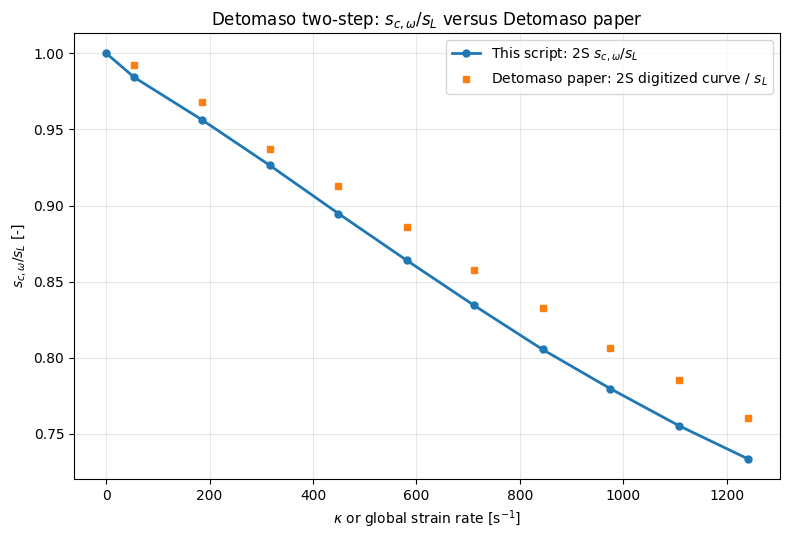

Computed sL0 used for this script: 323.2336 mm/s
sL0 used to normalize paper data: 323.2336 mm/s
Saved figure to:
/home/cilo479/Documents/cantera-tcd/samples/python/stretchedTF/2s_sc_omega_over_sL_vs_detomaso_paper.png


In [15]:

# =============================================================================
# PLOT BLOCK 2: TWO-STEP s_c,omega/sL VERSUS DETOMASO-PAPER TWO-STEP DATA
# =============================================================================

plot_case_against_paper(
    mechanism_cases[1]
)


In [16]:
# =============================================================================
# FINAL TABLE: sc_omega / sL comparison only
# =============================================================================
# This prints:
#   my sc_omega/sL
#   paper sc_omega/sL read directly from CSV
#   % difference
#
# No pandas required.
# No dimensional sc_omega column.
# No sL0 column.
#
# Assumption for paper CSV files:
#   x = kappa_global [1/s]
#   y = paper sc_omega/sL [-]

import csv
import math
from collections import defaultdict


table_rows = plot_results if "plot_results" in globals() else all_results


# -----------------------------------------------------------------------------
# Load paper curves directly from CSV
# -----------------------------------------------------------------------------

ADD_ZERO_REFERENCE_POINT = True


def load_paper_curve(csv_file):
    """
    Reads a CSV with columns:
        x, y

    x = kappa_global [1/s]
    y = paper sc_omega/sL [-]

    Duplicate x-values are averaged.
    """
    grouped_y = defaultdict(list)

    with open(csv_file, "r", newline="") as f:
        reader = csv.DictReader(f, skipinitialspace=True)

        for row in reader:
            x = float(row["x"])
            y = float(row["y"])
            grouped_y[x].append(y)

    curve = []

    for x, y_values in grouped_y.items():
        y_mean = sum(y_values) / len(y_values)
        curve.append((x, y_mean))

    if ADD_ZERO_REFERENCE_POINT:
        curve.append((0.0, 1.0))

    curve.sort(key=lambda pair: pair[0])

    return curve


gri_paper_curve = load_paper_curve("gri_scq_v_kappa.csv")
two_step_paper_curve = load_paper_curve("2s_scq_v_kappa.csv")


# -----------------------------------------------------------------------------
# Interpolation
# -----------------------------------------------------------------------------

def interp_linear(x_query, curve):
    """
    Linear interpolation.

    Returns nan if x_query is outside the paper curve range.
    """
    if len(curve) < 2:
        return math.nan

    x_min = curve[0][0]
    x_max = curve[-1][0]

    if x_query < x_min or x_query > x_max:
        return math.nan

    for i in range(len(curve) - 1):
        x0, y0 = curve[i]
        x1, y1 = curve[i + 1]

        if x0 <= x_query <= x1:
            if x1 == x0:
                return y0

            frac = (x_query - x0) / (x1 - x0)
            return y0 + frac * (y1 - y0)

    return math.nan


# -----------------------------------------------------------------------------
# Mechanism detection
# -----------------------------------------------------------------------------

def get_case_key(row):
    return str(row["case_key"])


def get_paper_curve_for_row(row):
    case_key = str(row["case_key"]).lower()
    label = str(row["label"]).lower()

    if "gri" in case_key or "gri" in label:
        return gri_paper_curve

    if (
        "2s" in case_key
        or "2s" in label
        or "2-step" in case_key
        or "2-step" in label
        or "2step" in case_key
        or "2step" in label
    ):
        return two_step_paper_curve

    return None


# -----------------------------------------------------------------------------
# Compute sL reference per mechanism from the free-flame row
# -----------------------------------------------------------------------------

sL_ref_by_case = {}

for row in table_rows:
    case_key = get_case_key(row)
    kappa = float(row["kappa_global"])

    if abs(kappa) < 1.0e-12:
        # For the free flame, sc_omega = sL.
        sL_ref_by_case[case_key] = float(row["sc_omega_mm_s"])


# Fallback if a free-flame row is missing for some reason
for row in table_rows:
    case_key = get_case_key(row)

    if case_key not in sL_ref_by_case:
        if "sL0_mm_s" in row:
            sL_ref_by_case[case_key] = float(row["sL0_mm_s"])
        else:
            raise RuntimeError(
                f"Could not find sL reference for case_key = {case_key}. "
                "Need either a kappa=0 free-flame row or row['sL0_mm_s']."
            )


# -----------------------------------------------------------------------------
# Formatting
# -----------------------------------------------------------------------------

def format_float(value, width=12, precision=5):
    if value is None or not math.isfinite(value):
        return f"{'nan':>{width}s}"

    return f"{value:{width}.{precision}f}"


# -----------------------------------------------------------------------------
# Print final table
# -----------------------------------------------------------------------------

print(
    "\n"
    "label | kappa_global [1/s] | my sc_omega/sL | "
    "paper sc_omega/sL | % diff vs paper | status"
)

print("-" * 115)

for row in sorted(
    table_rows,
    key=lambda row: (
        row["case_key"],
        float(row["kappa_global"]),
    ),
):
    case_key = get_case_key(row)
    kappa = float(row["kappa_global"])

    sc_omega_mm_s = float(row["sc_omega_mm_s"])
    sL_ref_mm_s = sL_ref_by_case[case_key]

    my_sc_omega_over_sL = sc_omega_mm_s / sL_ref_mm_s

    paper_curve = get_paper_curve_for_row(row)

    if paper_curve is None:
        paper_sc_omega_over_sL = math.nan
    else:
        paper_sc_omega_over_sL = interp_linear(kappa, paper_curve)

    if math.isfinite(paper_sc_omega_over_sL):
        percent_diff_vs_paper = (
            100.0
            * (my_sc_omega_over_sL - paper_sc_omega_over_sL)
            / paper_sc_omega_over_sL
        )
    else:
        percent_diff_vs_paper = math.nan

    print(
        f"{row['label']:20s} | "
        f"{kappa:18.3f} | "
        f"{my_sc_omega_over_sL:15.5f} | "
        f"{format_float(paper_sc_omega_over_sL, width=18, precision=5)} | "
        f"{format_float(percent_diff_vs_paper, width=15, precision=2)} | "
        f"{row['status']}"
    )


label | kappa_global [1/s] | my sc_omega/sL | paper sc_omega/sL | % diff vs paper | status
-------------------------------------------------------------------------------------------------------------------
Detomaso 2S $F=1$    |              0.000 |         1.00000 |            1.00000 |            0.00 | free-flame reference
Detomaso 2S $F=1$    |             54.288 |         0.98418 |            0.99241 |           -0.83 | converged
Detomaso 2S $F=1$    |            185.485 |         0.95624 |            0.96772 |           -1.19 | converged
Detomaso 2S $F=1$    |            316.682 |         0.92629 |            0.93734 |           -1.18 | converged
Detomaso 2S $F=1$    |            449.010 |         0.89474 |            0.91266 |           -1.96 | converged
Detomaso 2S $F=1$    |            581.338 |         0.86395 |            0.88608 |           -2.50 | converged
Detomaso 2S $F=1$    |            711.404 |         0.83438 |            0.85759 |           -2.71 | converged
Deto

In [15]:
## There is a consistent underprediction of Sc of 1-5% depending on stretch level. 
## This script was also tested on Cantera 3.0.0 and the same trend is seen
## It is independant of mechanism and transport model. 

## This difference could be due to differences in numerical setup (tolerances, width, transport properties, etc.)
## Since the underprediction is relatively consistent, values of Fth, Fsp, Fr should be similar to paper

## Continue to calculate Fth, Fsp, Fr...

In [16]:
# =============================================================================
# S-TF CONSTANTS AND FACTOR CALCULATION
# =============================================================================

import numpy as np
import math

# Target strain used for S-TF matching
ks_target_stf = 1450.0  # [1/s]

# Thickening factors to optimize
stf_thickening_factors = [
    1.0,
    2.0,
    5.0,
    7.0,
    10.0,
]

# Detomaso two-step simplified transport setting
Le0_stf = 1.4

# User-specified beta
beta_stf = -0.378

# Your convention:
# Detomaso multiplies source by Fr_detomaso.
# Your code divides source by Fr.
# Therefore your Fr = 1 / Fr_detomaso.
Fr_exponent_stf = -2.0

# X0 propagation-loop settings
stf_tol = 0.01         # 0.1% tolerance on epsilon
stf_max_iter = 100
stf_dX0_initial = 0.1


def compute_stf_factors_from_x0(
    F,
    X0,
    Le0=Le0_stf,
    beta=beta_stf,
    Fr_exponent=Fr_exponent_stf,
):
    """
    Compute S-TF factors from current X0.

        Fth = F

        Fsp = F^2 Le0 / [F + (Le0 - 1) X0]

        Fr = [1/sqrt(Fth) * (Fth/Fsp)^beta]^(-2)

    Here Fr is your reciprocal convention, because your code divides
    the chemical source term by Fr.

    Fth is fixed by the assigned thickening factor.
    Fsp and Fr change when X0 changes.
    """

    F = float(F)
    X0 = float(X0)

    Fth = F

    denominator = F + (Le0 - 1.0) * X0

    if denominator <= 0.0:
        raise ValueError(
            f"Invalid S-TF denominator: "
            f"F={F}, X0={X0}, denominator={denominator}"
        )

    Fsp = F**2.0 * Le0 / denominator

    Fr = (
        (
            1.0 / math.sqrt(Fth)
        )
        * (
            Fth / Fsp
        )**beta
    )**Fr_exponent

    Le_hat = Le0 * Fth / Fsp

    return {
        "F": F,
        "X0": X0,
        "Fth": float(Fth),
        "Fsp": float(Fsp),
        "Fr": float(Fr),
        "Le_hat": float(Le_hat),
    }

In [17]:
# =============================================================================
# NO-THICKENING TARGET FLAME
# =============================================================================

def solve_counterflow_case_no_thickening(
    case,
    boundary,
    kappa_target,
    domain_length,
):
    """
    Solve the true reference counterflow flame.

    No thickening.
    No S-TF call.
    No flame.flame.set_stretched_thickened_flame(...).

    This gives the target absolute Sc at ks_target.
    """

    Uu, Ub = inlet_velocities_for_target_kappa(
        kappa_target,
        boundary["rho_u"],
        boundary["rho_b"],
        domain_length,
    )

    gas = make_gas(
        case
    )

    flame = ct.CounterflowPremixedFlame(
        gas,
        width=domain_length,
    )

    apply_transport_model(
        flame,
        case["transport_model"],
    )

    flame.reactants.T = Tu
    flame.reactants.Y = boundary["Y_u"]
    flame.reactants.mdot = boundary["rho_u"] * Uu

    flame.products.T = boundary["T_b"]
    flame.products.Y = boundary["Y_b"]
    flame.products.mdot = boundary["rho_b"] * Ub

    flame.set_initial_guess(
        equilibrate=False,
    )

    flame.set_refine_criteria(
        **refine_criteria
    )

    # Critical for the Detomaso two-step simplified-transport case.
    apply_constant_transport_numbers(
        gas,
        case,
    )

    # ------------------------------------------------------------
    # NO THICKENING CALL HERE
    # ------------------------------------------------------------

    flame.solve(
        loglevel=loglevel,
        refine_grid=True,
        auto=True,
    )

    Tmax = float(
        np.max(
            np.asarray(
                flame.T,
                dtype=float,
            )
        )
    )

    if Tmax < Tu + 500.0:
        raise RuntimeError(
            f"Cold/extinguished no-thickening target solution at "
            f"kappa_target={kappa_target:g} 1/s."
        )

    Sc, integrated_fuel_rate = calculate_sc_omega(
        flame,
        boundary,
    )

    if (
        not np.isfinite(Sc)
        or Sc <= 0.0
    ):
        raise RuntimeError(
            f"Invalid target Sc at kappa_target={kappa_target:g} 1/s: {Sc}"
        )

    kappa_global = float(
        (
            abs(Uu)
            + abs(Ub)
        )
        / domain_length
    )

    return {
        "kappa_target": float(kappa_target),
        "kappa_global": kappa_global,
        "domain_length": float(domain_length),
        "Uu": float(Uu),
        "Ub": float(Ub),
        "Sc": float(Sc),
        "Sc_mm_s": float(Sc * 1000.0),
        "Tmax": Tmax,
        "n_points": int(flame.grid.size),
        "integrated_fuel_rate": float(integrated_fuel_rate),
        "flame": flame,
    }

In [18]:
# =============================================================================
# STRETCHED-THICKENED FLAME SOLVER
# =============================================================================

def solve_counterflow_case_stf(
    case,
    boundary,
    kappa_target,
    domain_length,
    Fth,
    Fsp,
    Fr,
):
    """
    Solve one counterflow premixed flame using S-TF factors.

    This is the trial flame used inside the X0 optimization loop.

    Uses your custom command:

        flame.flame.set_stretched_thickened_flame(Fth, Fsp, Fr)

    Important:
        calculate_sc_omega(...) returns the raw integrated-source value.
        For the thickened S-TF trial, compare Sc_raw/Fth against the
        no-thickening target Sc.
    """

    Uu, Ub = inlet_velocities_for_target_kappa(
        kappa_target,
        boundary["rho_u"],
        boundary["rho_b"],
        domain_length,
    )

    gas = make_gas(
        case
    )

    flame = ct.CounterflowPremixedFlame(
        gas,
        width=domain_length,
    )

    apply_transport_model(
        flame,
        case["transport_model"],
    )

    flame.reactants.T = Tu
    flame.reactants.Y = boundary["Y_u"]
    flame.reactants.mdot = boundary["rho_u"] * Uu

    flame.products.T = boundary["T_b"]
    flame.products.Y = boundary["Y_b"]
    flame.products.mdot = boundary["rho_b"] * Ub

    flame.set_initial_guess(
        equilibrate=False,
    )

    flame.set_refine_criteria(
        **refine_criteria
    )

    # Critical for the Detomaso two-step simplified-transport case.
    apply_constant_transport_numbers(
        gas,
        case,
    )

    # ------------------------------------------------------------
    # S-TF FACTORS APPLIED HERE
    # ------------------------------------------------------------
    flame.flame.set_stretched_thickened_flame(
        Fth,
        Fsp,
        Fr,
    )

    try:
        flame.flame.beta = beta_stf
    except AttributeError:
        pass

    flame.solve(
        loglevel=loglevel,
        refine_grid=True,
        auto=True,
    )

    Tmax = float(
        np.max(
            np.asarray(
                flame.T,
                dtype=float,
            )
        )
    )

    if Tmax < Tu + 500.0:
        raise RuntimeError(
            f"Cold/extinguished S-TF solution at "
            f"kappa_target={kappa_target:g} 1/s, "
            f"Fth={Fth:g}, Fsp={Fsp:g}, Fr={Fr:g}."
        )

    Sc_raw, integrated_fuel_rate = calculate_sc_omega(
        flame,
        boundary,
    )

    Sc = Sc_raw / Fr

    if (
        not np.isfinite(Sc)
        or Sc <= 0.0
    ):
        raise RuntimeError(
            f"Invalid S-TF Sc at "
            f"kappa_target={kappa_target:g} 1/s: {Sc}"
        )

    kappa_global = float(
        (
            abs(Uu)
            + abs(Ub)
        )
        / domain_length
    )

    return {
        "kappa_target": float(kappa_target),
        "kappa_global": kappa_global,
        "domain_length": float(domain_length),
        "Uu": float(Uu),
        "Ub": float(Ub),
        "Fth": float(Fth),
        "Fsp": float(Fsp),
        "Fr": float(Fr),
        "Sc_raw": float(Sc_raw),
        "Sc": float(Sc),
        "Sc_mm_s": float(Sc * 1000.0),
        "Tmax": Tmax,
        "n_points": int(flame.grid.size),
        "integrated_fuel_rate": float(integrated_fuel_rate),
        "flame": flame,
    }

In [19]:
# =============================================================================
# S-TF OBJECTIVE FUNCTION: ONE X0 TRIAL
# =============================================================================

stf_objective_cache = {}


def evaluate_stf_x0_trial(
    F,
    X0,
    case,
    boundary,
    domain_length,
    Sc_target,
    kappa_target=ks_target_stf,
):
    """
    Evaluate one X0 trial.

    Target:
        Sc_target = Sc from the no-thickening flame at ks_target.

    Trial:
        Sc_trial = Sc_raw/Fth from the S-TF flame with assigned F
        and current X0.

    Objective:
        epsilon = (Sc_target - Sc_trial) / Sc_target

    This matches absolute Sc, not Sc/sL0.
    """

    F = float(F)
    X0 = float(X0)

    cache_key = (
        case["label"],
        round(F, 8),
        round(X0, 8),
        round(kappa_target, 8),
        round(domain_length, 12),
    )

    if cache_key in stf_objective_cache:
        return stf_objective_cache[cache_key]

    factors = compute_stf_factors_from_x0(
        F=F,
        X0=X0,
    )

    result = solve_counterflow_case_stf(
        case=case,
        boundary=boundary,
        kappa_target=kappa_target,
        domain_length=domain_length,
        Fth=factors["Fth"],
        Fsp=factors["Fsp"],
        Fr=factors["Fr"],
    )

    Sc_trial = result["Sc"]

    epsilon = (
        Sc_target
        - Sc_trial
    ) / Sc_target

    output = {
        "F": F,
        "X0": X0,
        "Fth": factors["Fth"],
        "Fsp": factors["Fsp"],
        "Fr": factors["Fr"],
        "Le_hat": factors["Le_hat"],
        "Sc_raw": result["Sc_raw"],
        "Sc": Sc_trial,
        "Sc_target": Sc_target,
        "epsilon": float(epsilon),
        "epsilon_percent": float(100.0 * epsilon),
        "kappa_global": result["kappa_global"],
        "Tmax": result["Tmax"],
        "n_points": result["n_points"],
    }

    stf_objective_cache[cache_key] = output

    print(
        f"F={F:5.2f} | "
        f"X0={X0:10.5f} | "
        f"Fth={output['Fth']:10.5f} | "
        f"Fsp={output['Fsp']:10.5f} | "
        f"Fr={output['Fr']:12.6f} | "
        f"Le_hat={output['Le_hat']:9.5f} | "
        f"kappa={output['kappa_global']:10.3f} | "
        f"Sc_raw={output['Sc_raw']:12.7f} | "
        f"Sc/Fth={output['Sc']:12.7f} | "
        f"target={output['Sc_target']:12.7f} | "
        f"eps={output['epsilon_percent']:9.4f}%"
    )

    return output

In [20]:
# =============================================================================
# OPTIMIZE X0 FOR ONE THICKENING FACTOR
# =============================================================================

def optimize_stf_x0_for_F(
    F,
    case,
    boundary,
    domain_length,
    Sc_target,
    kappa_target=ks_target_stf,
    X0_initial=1.0,
    dX0_initial=stf_dX0_initial,
    tol=stf_tol,
    max_iter=stf_max_iter,
):
    """
    Optimize X0 for one assigned thickening factor F.

    For every F, including F = 1:

        1. Assign Fth = F.
        2. Guess X0.
        3. Compute Fsp and Fr from X0.
        4. Run S-TF flame.
        5. Compare Sc_raw/Fth against no-thickening Sc_target.
        6. Update X0 until epsilon is minimized.

    Fth stays fixed.
    Fsp and Fr change with X0.
    """

    F = float(F)

    if Le0_stf <= 1.0:
        raise NotImplementedError(
            "This X0 bound currently assumes Le0 > 1."
        )

    X0_min = -F / (Le0_stf - 1.0)

    print(
        "\n"
        + "=" * 150
    )

    print(
        f"Optimizing S-TF X0 for assigned thickening factor F = {F:g}"
    )

    print(
        f"Physical lower bound: X0 > {X0_min:.6f}"
    )

    print(
        "=" * 150
    )

    X0 = float(X0_initial)
    dX0 = float(dX0_initial)

    prev_eps = None
    best_result = None

    for iteration in range(
        1,
        max_iter + 1,
    ):
        try:
            result = evaluate_stf_x0_trial(
                F=F,
                X0=X0,
                case=case,
                boundary=boundary,
                domain_length=domain_length,
                Sc_target=Sc_target,
                kappa_target=kappa_target,
            )

        except Exception as err:
            print(
                f"Iter {iteration:3d}: X0={X0:10.5f} failed: "
                f"{type(err).__name__}: {err}"
            )

            dX0 *= -0.5
            X0_new = X0 + dX0

            if X0_new <= X0_min:
                X0_new = X0_min + 1.0e-3
                dX0 = X0_new - X0

            X0 = X0_new

            continue

        eps = result["epsilon"]

        result["iterations"] = iteration
        result["converged"] = abs(eps) < tol

        if (
            best_result is None
            or abs(eps) < abs(best_result["epsilon"])
        ):
            best_result = result

        print(
            f"Iter {iteration:3d}: "
            f"X0={X0:10.5f}, "
            f"dX0={dX0:10.5f}, "
            f"epsilon={eps: .6e}"
        )

        if abs(eps) < tol:
            print(
                f"\nConverged for F={F:g}: |epsilon| < {tol:g}"
            )

            return result

        if prev_eps is not None:
            if abs(eps) > abs(prev_eps):
                dX0 *= -0.5

                print(
                    f"  -> error increased, reversing direction; "
                    f"new dX0 = {dX0:.6f}"
                )

            else:
                dX0 *= 1.1

                print(
                    f"  -> error decreased, slightly increasing step; "
                    f"new dX0 = {dX0:.6f}"
                )

        X0_new = X0 + dX0

        if X0_new <= X0_min:
            X0_new = X0_min + 1.0e-3
            dX0 = X0_new - X0

            print(
                f"  -> enforcing X0 > X0_min, setting X0 = {X0_new:.6f}"
            )

        prev_eps = eps
        X0 = X0_new

    print(
        f"\nWarning: max_iter reached for F={F:g}. "
        f"Returning best result."
    )

    best_result["converged"] = False

    return best_result

In [21]:
# =============================================================================
# RUN FULL S-TF OPTIMIZATION IN CORRECT ORDER
# =============================================================================

def find_case_by_label_substring(
    mechanism_cases,
    substring,
):
    """
    Find a mechanism case by substring in its label.
    """

    substring = substring.lower()

    for case in mechanism_cases:
        if substring in case["label"].lower():
            return case

    raise ValueError(
        f"No mechanism case label contains substring: {substring}"
    )


# Use the Detomaso two-step case.
detomaso_two_step_case = find_case_by_label_substring(
    mechanism_cases,
    "Detomaso",
)

print(
    "\nPreparing Detomaso two-step reference case..."
)

boundary = build_boundary_state(
    detomaso_two_step_case
)

reference = solve_unstretched_flame(
    detomaso_two_step_case
)

scale_check = check_unstretched_flame_scales(
    detomaso_two_step_case,
    reference,
    boundary,
)

sL0 = reference["sL0"]

domain_length = (
    domain_length_multiplier
    * scale_check["delta_L0"]
)

print(
    f"sL0 = {sL0:.8f} m/s"
)

print(
    f"domain_length = {domain_length:.8e} m"
)

print(
    f"ks_target_stf = {ks_target_stf:.3f} 1/s"
)

# -------------------------------------------------------------------------
# Step 1: solve the TRUE no-thickening target flame.
# -------------------------------------------------------------------------

print(
    "\nSolving NO-THICKENING target flame at ks_target..."
)

target_result = solve_counterflow_case_no_thickening(
    case=detomaso_two_step_case,
    boundary=boundary,
    kappa_target=ks_target_stf,
    domain_length=domain_length,
)

Sc_target = target_result["Sc"]

print(
    "\nNO-THICKENING TARGET"
)

print(
    f"kappa_global = {target_result['kappa_global']:.6f} 1/s"
)

print(
    f"Sc_target = {Sc_target:.8f} m/s"
)

print(
    f"Sc_target/sL0 = {Sc_target / sL0:.8f}"
)

print(
    f"Tmax = {target_result['Tmax']:.2f} K"
)

print(
    f"points = {target_result['n_points']}"
)

# -------------------------------------------------------------------------
# Step 2: optimize X0 for each assigned thickening factor.
# -------------------------------------------------------------------------

stf_optimized_results = []

for F in stf_thickening_factors:
    result = optimize_stf_x0_for_F(
        F=F,
        case=detomaso_two_step_case,
        boundary=boundary,
        domain_length=domain_length,
        Sc_target=Sc_target,
        kappa_target=ks_target_stf,
        X0_initial=1.0,
        dX0_initial=stf_dX0_initial,
        tol=stf_tol,
        max_iter=stf_max_iter,
    )

    stf_optimized_results.append(
        result
    )

# -------------------------------------------------------------------------
# Final table.
# -------------------------------------------------------------------------

print(
    "\n\nFINAL OPTIMIZED S-TF FACTORS"
)

print(
    "F | X0 | Fth | Fsp | Fr | Le_hat | Sc_raw [m/s] | Sc_raw/Fth [m/s] | target Sc [m/s] | epsilon [%] | iters | converged"
)

print(
    "-" * 175
)

for result in stf_optimized_results:
    print(
        f"{result['F']:5.2f} | "
        f"{result['X0']:10.5f} | "
        f"{result['Fth']:10.5f} | "
        f"{result['Fsp']:10.5f} | "
        f"{result['Fr']:12.6f} | "
        f"{result['Le_hat']:10.5f} | "
        f"{result['Sc_raw']:14.8f} | "
        f"{result['Sc']:17.8f} | "
        f"{result['Sc_target']:14.8f} | "
        f"{result['epsilon_percent']:11.5f} | "
        f"{result['iterations']:5d} | "
        f"{result['converged']}"
    )


Preparing Detomaso two-step reference case...

Unstretched flame scale check: Detomaso 2S $F=1$
mechanism file                  = detomaso_propane_2step_nopea.yaml
transport model                 = simplified
sL0 from inlet velocity         = 0.32743047 m/s
sL0 from omega integral         = 0.32543917 m/s
omega integral / inlet ratio    = 0.99391841
------------------------------------------------------------------------------
T_u                             = 300.000 K
T_b used for delta_L0           = 2204.839 K
T_max in free flame             = 2207.011 K
max |dT/dx|                     = 4.552112e+06 K/m
------------------------------------------------------------------------------
delta_L0                        = 4.18451625e-04 m
delta_L0                        = 0.418452 mm
sL0 / delta_L0                  = 782.48 1/s
delta_L0 / sL0                  = 1.277986 ms
------------------------------------------------------------------------------
x at max |dT/dx|                = 14.

F= 7.00 | X0=   0.52821 | Fth=   7.00000 | Fsp=   9.51287 | Fr=    5.551222 | Le_hat=  1.03018 | kappa=  1450.000 | Sc_raw=   1.2145429 | Sc/Fth=   0.2187884 | target=   0.2260589 | eps=   3.2162%
Iter  10: X0=   0.52821, dX0=  -0.09744, epsilon= 3.216196e-02
  -> error decreased, slightly increasing step; new dX0 = -0.107179
F= 7.00 | X0=   0.42103 | Fth=   7.00000 | Fsp=   9.56976 | Fr=    5.526254 | Le_hat=  1.02406 | kappa=  1450.000 | Sc_raw=   1.2189542 | Sc/Fth=   0.2205751 | target=   0.2260589 | eps=   2.4258%
Iter  11: X0=   0.42103, dX0=  -0.10718, epsilon= 2.425808e-02
  -> error decreased, slightly increasing step; new dX0 = -0.117897
F= 7.00 | X0=   0.30313 | Fth=   7.00000 | Fsp=   9.63314 | Fr=    5.498747 | Le_hat=  1.01732 | kappa=  1450.000 | Sc_raw=   1.2247539 | Sc/Fth=   0.2227333 | target=   0.2260589 | eps=   1.4711%
Iter  12: X0=   0.30313, dX0=  -0.11790, epsilon= 1.471126e-02
  -> error decreased, slightly increasing step; new dX0 = -0.129687
F= 7.00 | X0=   

In [22]:
# =============================================================================
# COMPARE OPTIMIZED S-TF FACTORS AGAINST DETOMASO TABLE 4
# =============================================================================

# Detomaso Table 4 values.
# Note:
#   Detomaso Fr is the direct source-term multiplier.
#   Your Fr is the reciprocal because your implementation divides by Fr.
#
# Therefore:
#   Fr_user_convention = 1.0 / Fr_detomaso

detomaso_table4 = {
    1.0: {
        "X0": 1.00,
        "Fth": 1.000,
        "Fsp": 1.000,
        "Fr_detomaso": 1.000,
        "Le_hat": 1.400,
    },
    2.0: {
        "X0": 0.95,
        "Fth": 2.000,
        "Fsp": 2.353,
        "Fr_detomaso": 0.565,
        "Le_hat": 1.190,
    },
    5.0: {
        "X0": 0.62,
        "Fth": 5.000,
        "Fsp": 6.669,
        "Fr_detomaso": 0.249,
        "Le_hat": 1.050,
    },
    7.0: {
        "X0": -0.20,
        "Fth": 7.000,
        "Fsp": 9.913,
        "Fr_detomaso": 0.186,
        "Le_hat": 0.989,
    },
    10.0: {
        "X0": -1.20,
        "Fth": 10.000,
        "Fsp": 14.706,
        "Fr_detomaso": 0.134,
        "Le_hat": 0.952,
    },
}


def percent_difference(
    my_value,
    reference_value,
):
    """
    Percent difference relative to the reference value:

        100 * (my - reference) / reference
    """

    if abs(reference_value) < 1.0e-14:
        return np.nan

    return 100.0 * (
        my_value
        - reference_value
    ) / reference_value


stf_vs_detomaso_results = []

print(
    "\n\nCOMPARISON AGAINST DETOMASO TABLE 4"
)

print(
    "Note: Fr is compared using your reciprocal convention, Fr_user = 1 / Fr_detomaso."
)

print(
    "For X0, absolute difference is often more meaningful than % difference because X0 crosses zero."
)

print(
    "\n"
    "F | "
    "X0 my | X0 Det | dX0 | X0 diff [%] | "
    "Fsp my | Fsp Det | Fsp diff [%] | "
    "Fr my | Fr Det user | Fr diff [%] | "
    "Le_hat my | Le_hat Det | Le_hat diff [%]"
)

print(
    "-" * 190
)

for result in stf_optimized_results:
    F = float(
        result["F"]
    )

    if F not in detomaso_table4:
        print(
            f"Skipping F={F:g}: no Detomaso Table 4 reference value."
        )
        continue

    det = detomaso_table4[F]

    det_Fr_user = 1.0 / det["Fr_detomaso"]

    dX0 = result["X0"] - det["X0"]

    X0_pct_diff = percent_difference(
        result["X0"],
        det["X0"],
    )

    Fsp_pct_diff = percent_difference(
        result["Fsp"],
        det["Fsp"],
    )

    Fr_pct_diff = percent_difference(
        result["Fr"],
        det_Fr_user,
    )

    Le_hat_pct_diff = percent_difference(
        result["Le_hat"],
        det["Le_hat"],
    )

    row = {
        "F": F,
        "X0_my": result["X0"],
        "X0_detomaso": det["X0"],
        "dX0": dX0,
        "X0_percent_diff": X0_pct_diff,
        "Fsp_my": result["Fsp"],
        "Fsp_detomaso": det["Fsp"],
        "Fsp_percent_diff": Fsp_pct_diff,
        "Fr_my": result["Fr"],
        "Fr_detomaso_user_convention": det_Fr_user,
        "Fr_percent_diff": Fr_pct_diff,
        "Le_hat_my": result["Le_hat"],
        "Le_hat_detomaso": det["Le_hat"],
        "Le_hat_percent_diff": Le_hat_pct_diff,
    }

    stf_vs_detomaso_results.append(
        row
    )

    print(
        f"{F:5.2f} | "
        f"{row['X0_my']:9.5f} | "
        f"{row['X0_detomaso']:8.5f} | "
        f"{row['dX0']:9.5f} | "
        f"{row['X0_percent_diff']:11.4f} | "
        f"{row['Fsp_my']:9.5f} | "
        f"{row['Fsp_detomaso']:9.5f} | "
        f"{row['Fsp_percent_diff']:12.4f} | "
        f"{row['Fr_my']:10.6f} | "
        f"{row['Fr_detomaso_user_convention']:11.6f} | "
        f"{row['Fr_percent_diff']:11.4f} | "
        f"{row['Le_hat_my']:10.5f} | "
        f"{row['Le_hat_detomaso']:10.5f} | "
        f"{row['Le_hat_percent_diff']:14.4f}"
    )


print(
    "\nSUMMARY: MEAN ABSOLUTE PERCENT DIFFERENCE"
)

comparison_keys = [
    "Fsp_percent_diff",
    "Fr_percent_diff",
    "Le_hat_percent_diff",
]

for key in comparison_keys:
    values = [
        abs(row[key])
        for row in stf_vs_detomaso_results
        if np.isfinite(row[key])
    ]

    print(
        f"{key:24s}: {np.mean(values):10.5f}%"
    )



COMPARISON AGAINST DETOMASO TABLE 4
Note: Fr is compared using your reciprocal convention, Fr_user = 1 / Fr_detomaso.
For X0, absolute difference is often more meaningful than % difference because X0 crosses zero.

F | X0 my | X0 Det | dX0 | X0 diff [%] | Fsp my | Fsp Det | Fsp diff [%] | Fr my | Fr Det user | Fr diff [%] | Le_hat my | Le_hat Det | Le_hat diff [%]
----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------
 1.00 |   1.00000 |  1.00000 |   0.00000 |      0.0000 |   1.00000 |   1.00000 |       0.0000 |   1.000000 |    1.000000 |      0.0000 |    1.40000 |    1.40000 |         0.0000
 2.00 |   1.10000 |  0.95000 |   0.15000 |     15.7895 |   2.29508 |   2.35300 |      -2.4615 |   1.802375 |    1.769912 |      1.8342 |    1.22000 |    1.19000 |         2.5210
 5.00 |   0.79475 |  0.62000 |   0.17475 |     28.1847 |   6.58155 |   6.66900 |    